## Librerias

In [371]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
import nltk

## Importación y limpieza de datos

In [372]:
periodicos = ['eldiario','larazon', 'publico', 'tercerainformacion', 'elespanol']
df_list = []

for i in periodicos:
    path = f'datos\data_{i}.csv'

    if i == 'eldiario':
        df_i = pd.read_csv(path, sep=';', encoding='latin1')
    elif i == 'tercerainformacion':
        df_i = pd.read_csv(path, sep='|')
    else:
        df_i = pd.read_csv(path)

    df_list.append(df_i)

### Eliminación de duplicados y nivelación del dataset

Comprobamos uno a uno que todos los periodicos se han implementado de forma correcta.

#### El diario

In [373]:
df_list[0].head(5)

,periodico,titulo,texto,url
0,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...
1,eldiario.es,Juicio a Vivotecnia: cómo demostrar un exceso...,Hay asuntos que una no abandona al salir del j...,https://www.eldiario.es/caballodenietzsche/jui...
2,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...
3,eldiario.es,Mentiras y cintas de vídeo,Como un gélido bisturí explorador de las mise...,https://www.eldiario.es/aragon/el-prismatico/m...
4,eldiario.es,Vosotros sois la televisión,Un minuto y diez segundos. Eso es lo que dura ...,https://www.eldiario.es/aragon/el-prismatico/t...


In [374]:
len(df_list[0])

2500

In [375]:
print(df_list[0].duplicated().sum())

0


In [376]:
df_list[0] = df_list[0].drop_duplicates().dropna()[0:2000]

In [377]:
len(df_list[0])

2000

#### La razon

In [378]:
df_list[1].head(10)

,periodico,titulo,texto,url
0,la razon,El 1º de Mayo y el «Incidente de Haymarket»,Aquel incidente se expandió como una gota de a...,https://www.larazon.es/opinion/1-mayo-incident...
1,la razon,El 20% de la población que vive en España ya h...,Las altas tasas de paro de magrebíes y subsaha...,https://www.larazon.es/opinion/20-poblacion-qu...
2,la razon,613.000 viviendas prometidas y 0 construidas,Sánchez pretende desviar el tiro apuntando a l...,https://www.larazon.es/opinion/613000-vivienda...
3,la razon,¿Aldama es un mentiroso?,«A pesar del pintoresco optimismo que intentan...,https://www.larazon.es/opinion/aldama-mentiros...
4,la razon,Un año después del apagón y la obsesión antinu...,Mientras la Comisión Europea recomienda extend...,https://www.larazon.es/opinion/ano-despues-apa...
5,la razon,Ausencia de ejemplaridad,La credibilidad de los sindicatos no solo se c...,https://www.larazon.es/opinion/ausencia-ejempl...
6,la razon,La bomba de relojería de la regularización mas...,"Se desconoce, por ejemplo, el impacto esperado...",https://www.larazon.es/opinion/bomba-relojeria...
7,la razon,El camino de Mónica García al desastre,«La política madrileña se ha convertido en un ...,https://www.larazon.es/opinion/camino-monica-g...
8,la razon,Caos electoral en Perú: entre el ruido digital...,Un mandato obtenido en medio del desorden no r...,https://www.larazon.es/opinion/caos-electoral-...
9,la razon,La cara oculta de los «éxitos» económicos de P...,La bonanza económica de la que tanto presume P...,https://www.larazon.es/opinion/cara-oculta-exi...


In [379]:
len(df_list[1])

2106

In [380]:
print(df_list[1].duplicated().sum())

0


In [381]:
df_list[1] = df_list[1].drop_duplicates().dropna()[0:2000]

In [382]:
len(df_list[1])

2000

#### Publico

In [383]:
df_list[2].head(5)

,periodico,titulo,texto,url
0,Público,Subtramas que trascienden Andalucía,"Andalucía pide protagonismo en primavera, entr...",https://www.publico.es/opinion/columnas/subtra...
1,Público,Elige tu propia aventura,Estos últimos días se están celebrando a la ve...,https://www.publico.es/opinion/columnas/elige-...
2,Público,Escabeche nacional,Se conocieron en un curso de escabeches. Al sa...,https://www.publico.es/opinion/columnas/escabe...
3,Público,Lo municipal es importante en sí y abre bases ...,El debate actual entre partidos y liderazgos d...,https://www.publico.es/opinion/columnas/munici...
4,Público,Supremacía nazional,"Eran las 7:30 de la mañana cuando Anne, enferm...",https://www.publico.es/opinion/columnas/suprem...


In [384]:
len(df_list[2])

2500

In [385]:
print(df_list[2].duplicated().sum())

122


In [386]:
df_list[2] = df_list[2].drop_duplicates().dropna()[0:2000]

In [387]:
len(df_list[2])

2000

#### Tercera informacion

In [388]:
df_list[3].head(5)

,periodico,titulo,texto,url
0,Tercera Información,Nos estamos jugando la democracia,FACUA • Rubén Sánchez • Opinión • 02/05/2026 E...,https://www.tercerainformacion.es/opinion/02/0...
1,Tercera Información,Exigimos al gobierno sionista la libertad sin ...,Soldepaz Pachakuti • Opinión • 02/05/2026 Exig...,https://www.tercerainformacion.es/opinion/02/0...
2,Tercera Información,Libertad inmediata de Thiago Ávila y Saif Abu ...,Con preocupación y alarma hemos recibido el 1 ...,https://www.tercerainformacion.es/opinion/02/0...
3,Tercera Información,"1º de Mayo. Paz, techo y vida digna. Queremos ...",Izquierda Unida • Opinión • 01/05/2026 En este...,https://www.tercerainformacion.es/opinion/01/0...
4,Tercera Información,Nace en Moscú Red Socialista Internacional con...,Rafael Méndez • Opinión • 01/05/2026 “Estamos ...,https://www.tercerainformacion.es/opinion/01/0...


In [389]:
len(df_list[3])

2000

In [390]:
print(df_list[3].duplicated().dropna().sum())

0


In [391]:
df_list[3] = df_list[3].drop_duplicates().dropna()[0:2000]

In [392]:
len(df_list[3])

2000

#### El español

In [393]:
df_list[4].head(5)

,periodico,titulo,texto,url
0,el español,"albert rivera, entre escila y caribdis","a medida que transcurren los días, desde el fi...",https://www.elespanol.com/opinion/carta-del-di...
1,el español,la elección de isabel perelló demuestra que la...,reunión del pleno del consejo general del pode...,https://www.elespanol.com/opinion/editoriales/...
2,el español,por qué le hablas a tu novio como si fuese una...,"fotograma de alta fidelidad. el otro día, mi a...",https://www.elespanol.com/opinion/columnas/202...
3,el español,"una instrucción extemporánea, mal razonada y c...","carlos mazón, en su comparecencia en el congre...",https://www.elespanol.com/opinion/editoriales/...
4,el español,"montero maquilla la financiación: más dinero, ...",la ministra maría jesús montero.mariscalagenci...,https://www.elespanol.com/opinion/tribunas/202...


In [394]:
len(df_list[4])

2192

In [395]:
print(df_list[4].duplicated().sum())

0


In [396]:
df_list[4] = df_list[4].drop_duplicates().dropna()[0:2000]

In [397]:
len(df_list[4])

2000

### Generación del conjunto de datos

Unimos todos los periodicos en un único dataframe.

In [398]:
df_raw = pd.concat(df_list, ignore_index=True)

In [399]:
len(df_raw)

10000

In [400]:
df_raw.isna().sum()

periodico    0
titulo       0
texto        0
url          0
dtype: int64

### Limpieza de los datos para el estudio de NLP

Eliminamos de la columna texto los signos de puntuación, las stop_words y los valores numéricos.

In [401]:
df = df_raw.copy()

In [402]:
nltk.download('stopwords')

# Cargar las stop words en español
stop_words_es = set(stopwords.words('spanish'))

# Función de limpieza
def clean_text(texto):
    
    if not isinstance(texto, str):
        return texto

    # Convertimos todo el texto a minusculas
    texto = texto.lower()
    
    # Eliminamos los valores numéricos
    texto = re.sub(r'\d+', '', texto)
    
    # Eliminamos los signos de puntuación (dejando solo letras y espacios)
    texto = re.sub(r'[^\w\s]|_', '', texto)
    
    # Eliminamos las stop words
    palabras = texto.split()
    palabras_limpias = [palabra for palabra in palabras if palabra not in stop_words_es]
    
    return ' '.join(palabras_limpias)

# Aplicamos la función de limpieza
df['texto_clean'] = df_raw['texto'].apply(clean_text)

# Verificamos los resultados
df['texto_clean'].head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joanm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    competición visualizaciones vídeo impactante d...
1    asuntos abandona salir juzgado casos quedan ad...
2    competición visualizaciones vídeo impactante d...
3    gélido bisturí explorador miserias humanas def...
4    minuto diez segundos dura vídeo informativos t...
Name: texto_clean, dtype: object

In [403]:
df.to_csv('datos_clean.csv', index=False)

### Análisis de polaridad y topic modeling

In [404]:
# Descargamos "stopwords"
nltk.download('stopwords')
stop_words_es = stopwords.words('spanish')

# ==========================================
# PARTE A: Análisis de Polaridad
# ==========================================

# Función para calcular la polaridad (de -1.0 a 1.0)
def calcular_polaridad(texto):
    # Nota: TextBlob funciona nativamente en inglés. 
    # Usamos una traducción interna rápida al inglés para evaluar textos en español.
    try:
        analisis = TextBlob(texto).translate(from_lang='es', to='en')
        return analisis.sentiment.polarity
    except:
        # En caso de error de conexión con el traductor, usamos el original
        return TextBlob(texto).sentiment.polarity

# Aplicamos la función y creamos una nueva columna
df['polaridad'] = df['texto_clean'].apply(calcular_polaridad)

# Etiquetamos el resultado para hacerlo más legible
df['sentimiento'] = df['polaridad'].apply(
    lambda p: 'Positivo' if p > 0.1 else ('Negativo' if p < -0.1 else 'Neutral')
)

# ==========================================
# PARTE B: Topic Modeling (LDA)
# ==========================================

# Convertimos el texto a una matriz matemática contando las palabras
vectorizador = CountVectorizer(stop_words=stop_words_es, max_df=0.9, min_df=1)
matriz_palabras = vectorizador.fit_transform(df['texto_clean'])

# Entrenamos el modelo LDA. Aquí le pedimos que busque 3 temas principales.
numero_temas = 10
lda = LatentDirichletAllocation(n_components=numero_temas, random_state=42)
lda.fit(matriz_palabras)

# Asignamos el tema dominante a cada noticia original
temas_asignados = lda.transform(matriz_palabras)
df['id_tema'] = temas_asignados.argmax(axis=1)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joanm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [405]:
# ==========================================
# PARTE C: Visualizar Resultados
# ==========================================

# Función para ver las palabras más repetidas de cada tema creado
palabras = vectorizador.get_feature_names_out()
for idx, tema in enumerate(lda.components_):
    palabras_clave = [palabras[i] for i in tema.argsort()[:-8 - 1:-1]]
    print(f"Tema {idx}: {', '.join(palabras_clave)}")

Tema 0: guerra, israel, irán, rusia, ucrania, unidos, militar, parte
Tema 1: trump, unidos, eeuu, guerra, mundo, venezuela, internacional, pueblo
Tema 2: animales, niños, epstein, niñas, animal, gatos, infancia, menores
Tema 3: aragón, zaragoza, madrid, diario, españa, prismático, eldiarioesaragon, firman
Tema 4: derecho, ley, derechos, españa, caso, años, justicia, tribunal
Tema 5: sánchez, gobierno, pp, si, psoe, presidente, partido, españa
Tema 6: do, non, da, animales, unha, as, dos, ou
Tema 7: si, ser, años, mujeres, vida, hace, siempre, vez
Tema 8: si, sino, españa, política, social, gobierno, millones, puede
Tema 9: murcia, ia, solo, salud, región, personas, países, desarrollo


In [406]:
df.head(5)

,periodico,titulo,texto,url,texto_clean,polaridad,sentimiento,id_tema
0,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...,competición visualizaciones vídeo impactante d...,0.10,Neutral,3
1,eldiario.es,Juicio a Vivotecnia: cómo demostrar un exceso...,Hay asuntos que una no abandona al salir del j...,https://www.eldiario.es/caballodenietzsche/jui...,asuntos abandona salir juzgado casos quedan ad...,0.06,Neutral,7
2,eldiario.es,La resaca de El Alcoraz,En la competición de visualizaciones del vídeo...,https://www.eldiario.es/aragon/el-prismatico/r...,competición visualizaciones vídeo impactante d...,0.10,Neutral,3
3,eldiario.es,Mentiras y cintas de vídeo,Como un gélido bisturí explorador de las mise...,https://www.eldiario.es/aragon/el-prismatico/m...,gélido bisturí explorador miserias humanas def...,0.30,Positivo,5
4,eldiario.es,Vosotros sois la televisión,Un minuto y diez segundos. Eso es lo que dura ...,https://www.eldiario.es/aragon/el-prismatico/t...,minuto diez segundos dura vídeo informativos t...,0.00,Neutral,7


In [407]:
np.unique(df['periodico'])

array(['Público', 'Tercera Información', 'el español', 'eldiario.es',
       'la razon'], dtype=object)

In [411]:
df_pol = pd.DataFrame()
sel_tema = 0

list_dic = []

periodicos = df['periodico'].unique()

for i in periodicos:
    
    df_sub = df[(df['periodico'] == i) & (df['id_tema'] == sel_tema)]

    dic = {
        'Periodico': i,
        'Positivo': len(df_sub[df_sub['sentimiento'] == 'Positivo']),
        'Negativo': len(df_sub[df_sub['sentimiento'] == 'Negativo']),
        'Neutral': len(df_sub[df_sub['sentimiento'] == 'Neutral'])
    }
    list_dic.append(dic)

df_pol = pd.DataFrame(list_dic)
print(df_pol)

             Periodico  Positivo  Negativo  Neutral
0          eldiario.es        10        12       27
1             la razon        28        23       88
2              Público        23        38      192
3  Tercera Información        35        46      133
4           el español        34        59      151


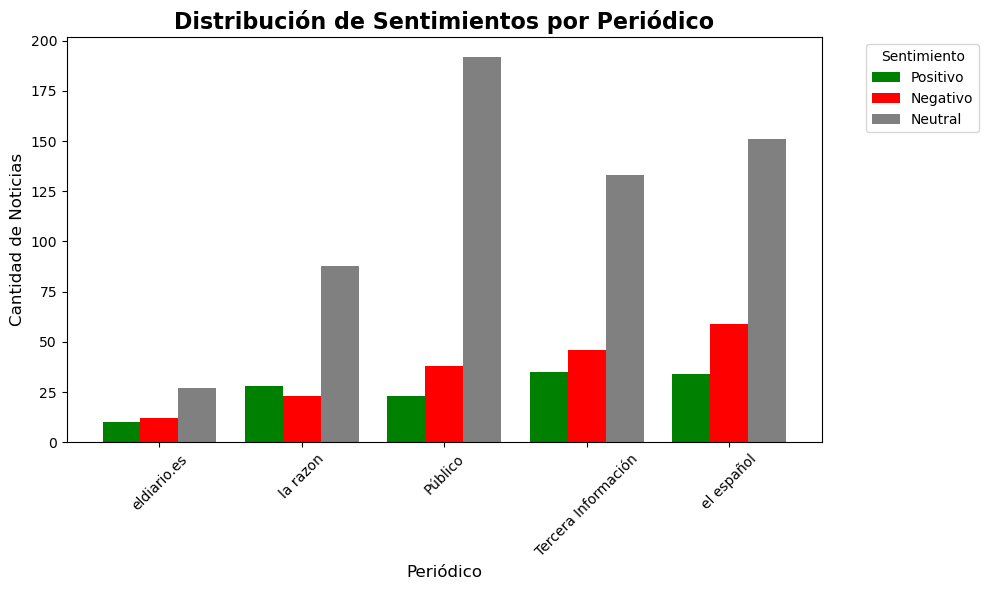

In [416]:
datos_grafica = df_pol.set_index('Periodico')[['Positivo', 'Negativo', 'Neutral']]
datos_grafica.plot(kind='bar', figsize=(10, 6), color=['green', 'red', 'gray'], width=0.8)
plt.title('Distribución de Sentimientos por Periódico', fontsize=16, fontweight='bold')
plt.xlabel('Periódico', fontsize=12)
plt.ylabel('Cantidad de Noticias', fontsize=12)
plt.xticks(rotation=45) 
plt.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Temas por periodico

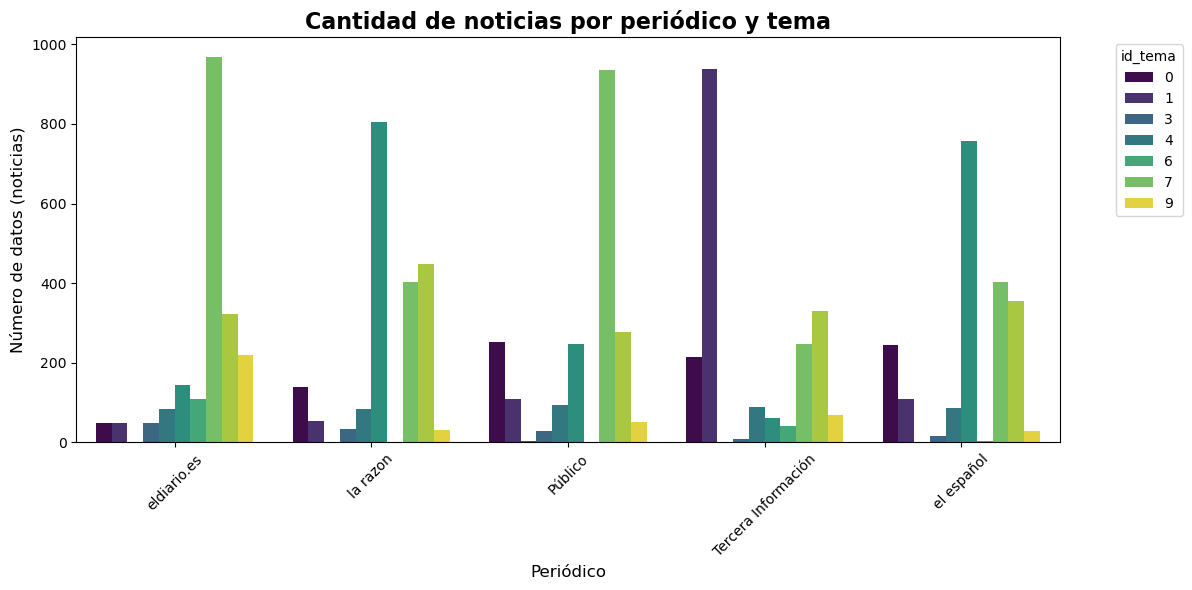

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='periodico', hue='id_tema', palette='viridis')
plt.title('Cantidad de noticias por periódico y tema', fontsize=16, fontweight='bold')
plt.xlabel('Periódico', fontsize=12)
plt.ylabel('Número de datos (noticias)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='id_tema', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()